# Проект обучение с учителем: качество модели

Описание проекта

Интернет-магазин «В один клик» предлагает широкий ассортимент товаров — от товаров для детей и дома до мелкой бытовой техники, косметики и продуктов питания. В условиях современной конкуренции за внимание потребителей компания сталкивается с необходимостью внедрения персонализированных предложений для поддержания активности своих постоянных клиентов. Привлечение новых покупателей стало менее эффективным, ведь значительная часть целевой аудитории уже знакома с брендом. Поэтому основное внимание теперь направлено на удержание существующих клиентов и увеличение их активности.

В этом проекте наша задача — разработать решение на основе машинного обучения, которое позволит предлагать клиентам персонализированные предложения, учитывая их предпочтения и покупательское поведение. Используя данные о покупательской активности, мы сможем создать модель, способную рекомендовать наиболее подходящие товары, что не только повысит вовлечённость клиентов, но и увеличит продажи магазина за счёт более точной и персонализированной коммуникации.

Описание данных

market_file.csv
Таблица, которая содержит данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении.

id — номер покупателя в корпоративной базе данных.

Покупательская активность — рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень».

Тип сервиса — уровень сервиса, например «премиум» и «стандарт».

Разрешить сообщать — информация о том, можно ли присылать покупателю дополнительные предложения о товаре. Согласие на это даёт покупатель.

Маркет_актив_6_мес — среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев. Это значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента.

Маркет_актив_тек_мес — количество маркетинговых коммуникаций в текущем месяце.

Длительность — значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте.

Акционные_покупки — среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев.

Популярная_категория — самая популярная категория товаров у покупателя за последние 6 месяцев.

Средний_просмотр_категорий_за_визит — показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца.

Неоплаченные_продукты_штук_квартал — общее число неоплаченных товаров в корзине за последние 3 месяца.

Ошибка_сервиса — число сбоев, которые коснулись покупателя во время посещения сайта.

Страниц_за_визит — среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца.

market_money.csv
Таблица с данными о выручке, которую получает магазин с покупателя, то есть сколько покупатель всего потратил за период взаимодействия с сайтом.

id — номер покупателя в корпоративной базе данных.

Период — название периода, во время которого зафиксирована выручка. Например, 'текущий_месяц' или 'предыдущий_месяц'.

Выручка — сумма выручки за период.


market_time.csv
Таблица с данными о времени (в минутах), которое покупатель провёл на сайте в течение периода.

id — номер покупателя в корпоративной базе данных.

Период — название периода, во время которого зафиксировано общее время.

минут — значение времени, проведённого на сайте, в минутах.


money.csv
Таблица с данными о среднемесячной прибыли покупателя за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю.

id — номер покупателя в корпоративной базе данных.

Прибыль — значение прибыли.


## Шаг 1. Загрузка и изучение данных

In [1]:
!pip install phik
!pip install shap
!pip install -Uq scikit-learn


     |████████████████████████████████| 686 kB 1.2 MB/s eta 0:00:01
     |████████████████████████████████| 539 kB 1.1 MB/s eta 0:00:01


In [2]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from phik import resources, report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    OrdinalEncoder,
)
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import shap

In [ ]:
# Сохраним датафреймы в переменные
try:
    market_file = pd.read_csv('/datasets/market_file.csv')
    market_money = pd.read_csv('/datasets/market_money.csv')
    market_time = pd.read_csv('/datasets/market_time.csv')
    money = pd.read_csv('/datasets/money.csv', sep=';', decimal=',')
except FileNotFoundError:
    try:
        market_file = pd.read_csv('/content/market_file.csv')
        market_money = pd.read_csv('/content/market_money.csv')
        market_time = pd.read_csv('/content/market_time.csv')
        money = pd.read_csv('/content/money.csv', sep=';', decimal=',')
    except FileNotFoundError:
        market_file = pd.read_csv('https://code.s3.yandex.net/datasets/market_file.csv')
        market_money = pd.read_csv('https://code.s3.yandex.net/datasets/market_money.csv')
        market_time = pd.read_csv('https://code.s3.yandex.net/datasets/market_time.csv')
        money = pd.read_csv('https://code.s3.yandex.net/datasets/money.csv', sep=';', decimal=',')

In [4]:
# Изучим основной датафрейм
display(market_file.head())
market_file.info()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

In [5]:
# Изучим таблицу с выручками
display(market_money.head())
market_money.info()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


In [6]:
# Изучим таблицу с периодами
display(market_time.head())
market_time.info()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


In [7]:
# Изучим таблицу с прибылью
display(money.head())
money.info()

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


Изучив данные, видим, что данные соотвествуют описанию. Пропусков нет. Во всех датафреймах есть общий столбец 'id'. Можно приступать к анализу.

## Шаг 2. Предобработка данных

Проверю ещё точно на пропуски, если не заметил где-то, а то таблиц много.

In [8]:
market_file.isnull().sum()

id                                     0
Покупательская активность              0
Тип сервиса                            0
Разрешить сообщать                     0
Маркет_актив_6_мес                     0
Маркет_актив_тек_мес                   0
Длительность                           0
Акционные_покупки                      0
Популярная_категория                   0
Средний_просмотр_категорий_за_визит    0
Неоплаченные_продукты_штук_квартал     0
Ошибка_сервиса                         0
Страниц_за_визит                       0
dtype: int64

In [9]:
market_money.isnull().sum()

id         0
Период     0
Выручка    0
dtype: int64

In [10]:
market_time.isnull().sum()

id        0
Период    0
минут     0
dtype: int64

In [11]:
money.isnull().sum()

id         0
Прибыль    0
dtype: int64

Теперь поищем дубликаты.

In [12]:
market_file.duplicated().sum()

0

In [13]:
market_money.duplicated().sum()

0

In [14]:
market_time.duplicated().sum()

0

In [15]:
money.duplicated().sum()

0

In [16]:
# Создадим общий файл с датафреймами для обработки
dataframes = [market_file, market_money, market_time, money]

In [17]:
# Проверим уникальные значения в нечисловых столбцах
for i, df in enumerate(dataframes):
    print(f"DataFrame {i+1}")
    non_numeric_columns = df.select_dtypes(include=['object']).columns
    for column in non_numeric_columns:
        print(f"Уникальные значения в столбце '{column}':")
        print(df[column].unique())
    print("\n")

DataFrame 1
Уникальные значения в столбце 'Покупательская активность':
['Снизилась' 'Прежний уровень']
Уникальные значения в столбце 'Тип сервиса':
['премиум' 'стандартт' 'стандарт']
Уникальные значения в столбце 'Разрешить сообщать':
['да' 'нет']
Уникальные значения в столбце 'Популярная_категория':
['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']


DataFrame 2
Уникальные значения в столбце 'Период':
['препредыдущий_месяц' 'текущий_месяц' 'предыдущий_месяц']


DataFrame 3
Уникальные значения в столбце 'Период':
['текущий_месяц' 'предыдцщий_месяц']


DataFrame 4




Исправим опечатки в столбце 'Тип сервиса' в датафрейме market_file и в столбце 'Период' в market_time.

In [18]:
# Исправим опечатку в столбце "Тип сервиса"
market_file['Тип сервиса'] = market_file['Тип сервиса'].replace('стандартт', 'стандарт')

In [19]:
# Исправим опечатку в столбце 'Период'
market_time['Период'] = market_time['Период'].replace('предыдцщий_месяц', 'предыдущий_месяц')

In [20]:
# Создадим функцию для постройки графиков числовых стобцов
def simple_boxplots(df_list):
    for df in df_list:
        numeric_columns = df.select_dtypes(include=[np.number]).columns
        for column in numeric_columns:
            if column != 'id':
                plt.figure(figsize=(6, 4))
                sns.boxplot(data=df[column], color="lightblue")
                plt.title(f'Boxplot для {column}')
                plt.show()


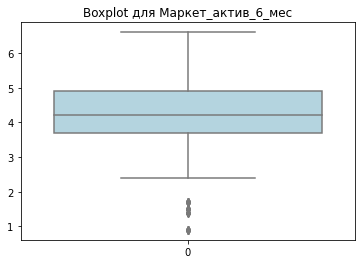

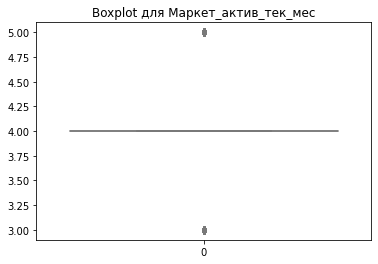

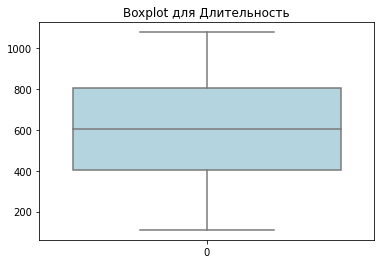

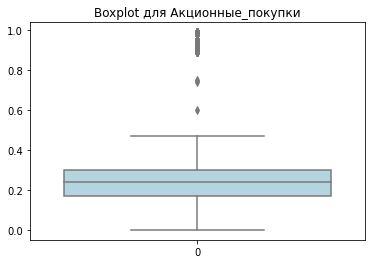

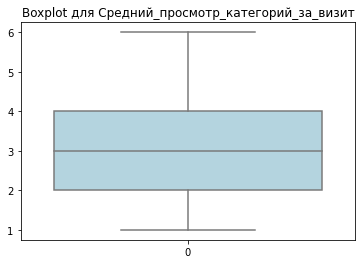

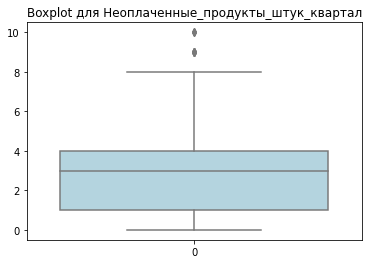

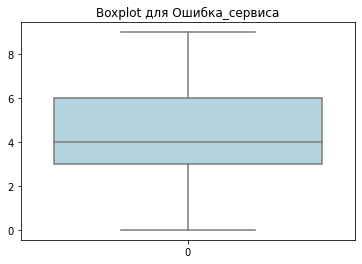

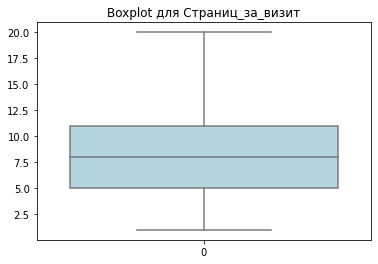

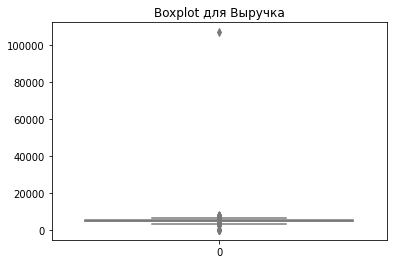

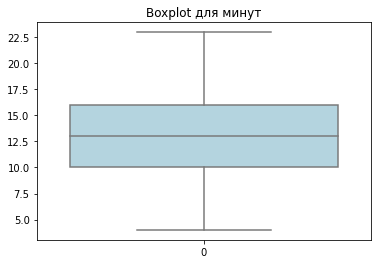

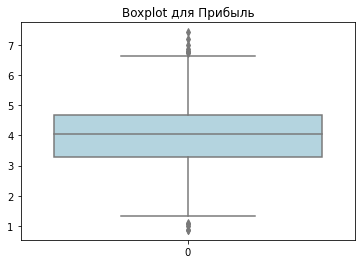

In [21]:
# Применим функцию к общему файлу датафреймов
simple_boxplots(dataframes)

На графике выручки есть выброс или выбросы свыше 100000, надо разобраться.

In [22]:
market_money[market_money['Выручка'] > 100000]

,id,Период,Выручка
98,215380,текущий_месяц,106862.2


Изучим все даные с этим id.

In [23]:
display(market_file[market_file['id'] == 215380])

display(market_money[market_money['id'] == 215380])

display(market_time[market_time['id'] == 215380])

display(money[money['id'] == 215380])

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
32,215380,Снизилась,премиум,нет,1.7,4,637,0.94,Техника для красоты и здоровья,3,2,4,7


,id,Период,Выручка
96,215380,препредыдущий_месяц,5051.0
97,215380,предыдущий_месяц,6077.0
98,215380,текущий_месяц,106862.2


,id,Период,минут
64,215380,предыдущий_месяц,12
65,215380,текущий_месяц,14


,id,Прибыль
32,215380,3.88


В остальном данные ничем не примечательные, возможно возникла ошибка какая-то или опечатка, т.к. выброс всего один, то можно не гадать и удалить, это не нанесёт критического ущерба данным. Или даже если это настоящее поведение покупателя, то лучше такой выброс удалить т.к. на пользу моделям он не пойдёт.

In [24]:
# Удаляем из всех датафреймов
market_file = market_file.query('id != 215380').reset_index(drop=True)
market_money = market_money.query('id != 215380').reset_index(drop=True)
market_time = market_time.query('id != 215380').reset_index(drop=True)
money = money.query('id != 215380').reset_index(drop=True)

In [25]:
market_file.columns = market_file.columns.str.replace(' ', '_')

In [26]:
market_file.head()

,id,Покупательская_активность,Тип_сервиса,Разрешить_сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


Проверили пропуски и дубликаты во всех датафреймах, исправили опечатки, удалили один выброс, привели столбцы к одному виду.

## Шаг 3. Исследовательский анализ данных

Отберём покупателей, которые совершали покупки за последние три месяца

Построим раздельные графики для клиентов у которых активность снизилась и осталась на прежнем уровне.

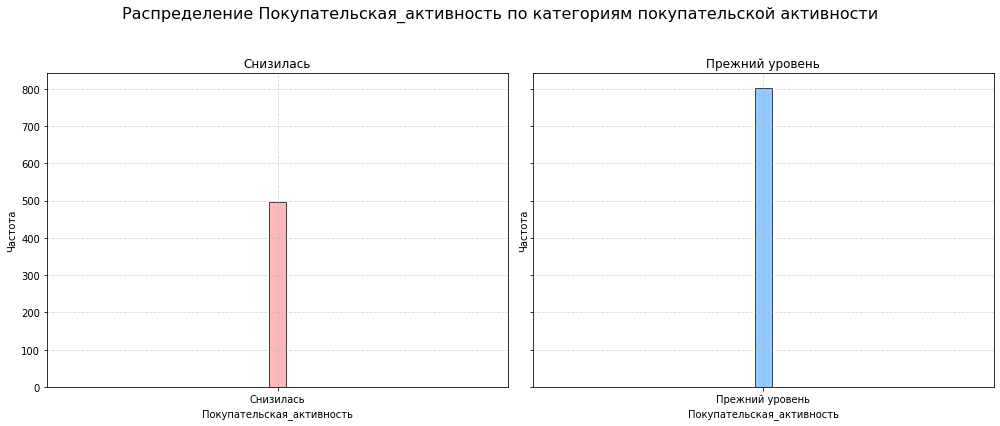


Описательная статистика для Покупательская_активность по категориям:

Категория: Снизилась
                          count unique        top freq
Покупательская_активность   497      1  Снизилась  497

Категория: Прежний уровень
                          count unique              top freq
Покупательская_активность   802      1  Прежний уровень  802


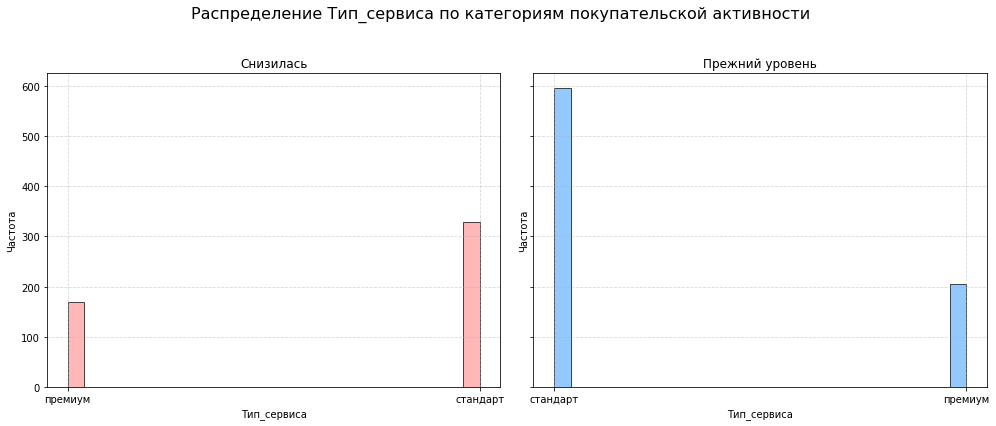


Описательная статистика для Тип_сервиса по категориям:

Категория: Снизилась
            count unique       top freq
Тип_сервиса   497      2  стандарт  328

Категория: Прежний уровень
            count unique       top freq
Тип_сервиса   802      2  стандарт  596


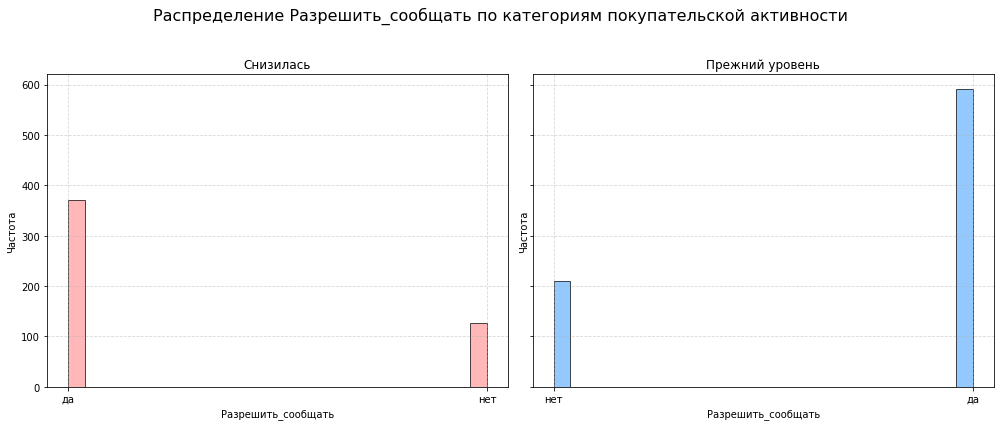


Описательная статистика для Разрешить_сообщать по категориям:

Категория: Снизилась
                   count unique top freq
Разрешить_сообщать   497      2  да  371

Категория: Прежний уровень
                   count unique top freq
Разрешить_сообщать   802      2  да  591


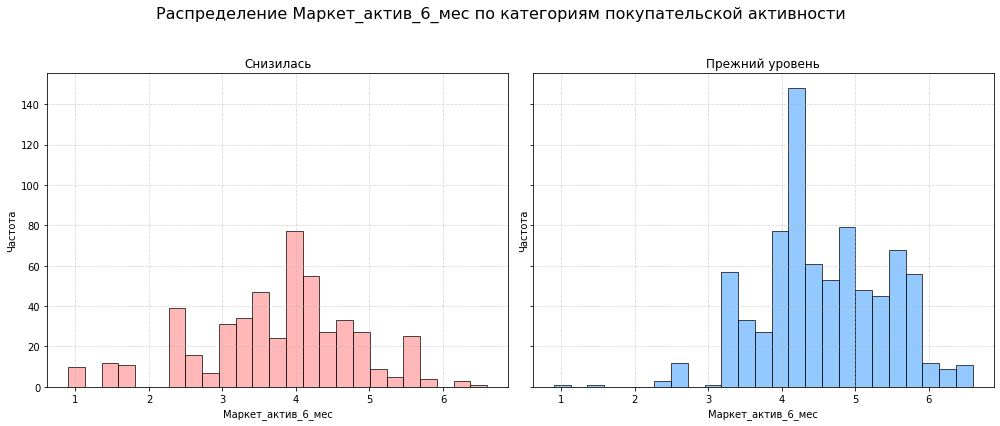


Описательная статистика для Маркет_актив_6_мес по категориям:

Категория: Снизилась
                    count      mean       std  min  25%  50%  75%  max
Маркет_актив_6_мес  497.0  3.748491  1.050424  0.9  3.1  3.9  4.4  6.6

Категория: Прежний уровень
                    count      mean       std  min  25%  50%    75%  max
Маркет_актив_6_мес  802.0  4.570075  0.848618  0.9  4.0  4.4  5.275  6.6


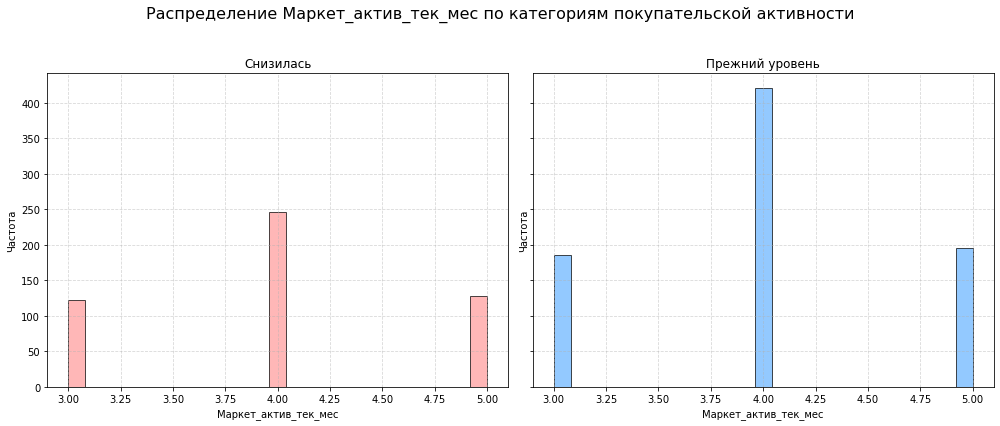


Описательная статистика для Маркет_актив_тек_мес по категориям:

Категория: Снизилась
                      count      mean       std  min  25%  50%  75%  max
Маркет_актив_тек_мес  497.0  4.012072  0.709849  3.0  4.0  4.0  5.0  5.0

Категория: Прежний уровень
                      count      mean       std  min  25%  50%  75%  max
Маркет_актив_тек_мес  802.0  4.011222  0.689586  3.0  4.0  4.0  4.0  5.0


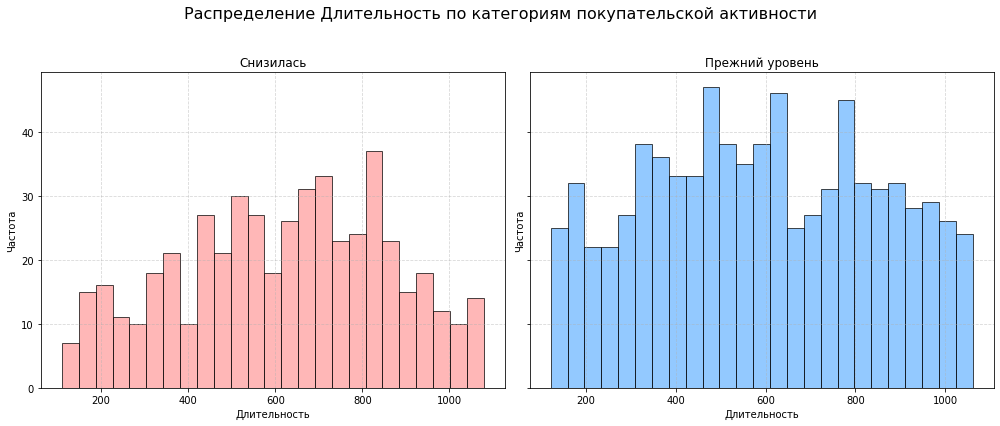


Описательная статистика для Длительность по категориям:

Категория: Снизилась
              count        mean        std    min    25%    50%    75%     max
Длительность  497.0  619.849095  240.18134  110.0  449.0  633.0  811.0  1079.0

Категория: Прежний уровень
              count        mean         std    min    25%    50%     75%  \
Длительность  802.0  590.730673  255.330179  121.0  382.5  590.0  798.75   

                 max  
Длительность  1061.0  


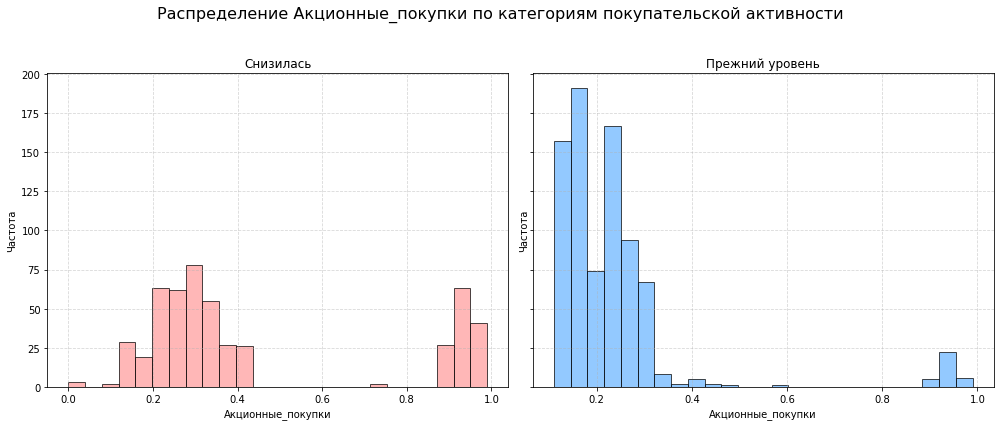


Описательная статистика для Акционные_покупки по категориям:

Категория: Снизилась
                   count     mean       std  min   25%   50%   75%   max
Акционные_покупки  497.0  0.44998  0.305529  0.0  0.24  0.31  0.89  0.99

Категория: Прежний уровень
                   count      mean       std   min   25%   50%   75%   max
Акционные_покупки  802.0  0.238367  0.160599  0.11  0.15  0.21  0.26  0.99


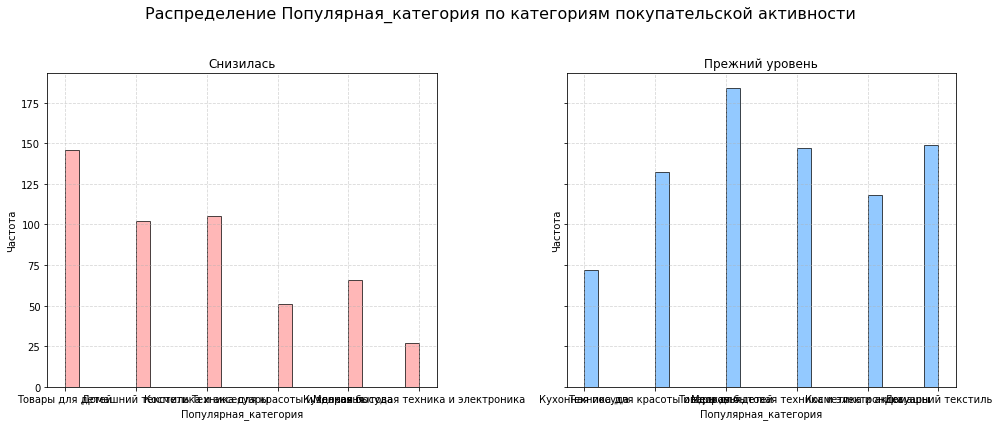


Описательная статистика для Популярная_категория по категориям:

Категория: Снизилась
                     count unique               top freq
Популярная_категория   497      6  Товары для детей  146

Категория: Прежний уровень
                     count unique               top freq
Популярная_категория   802      6  Товары для детей  184


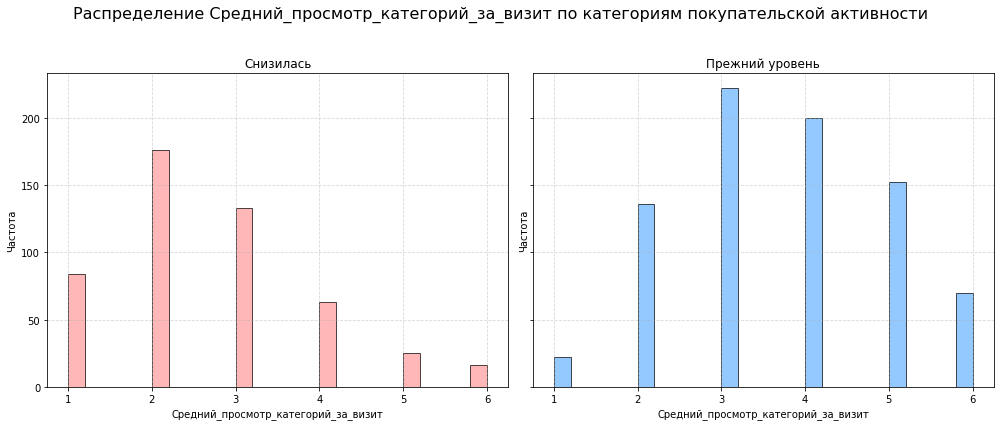


Описательная статистика для Средний_просмотр_категорий_за_визит по категориям:

Категория: Снизилась
                                     count      mean       std  min  25%  50%  \
Средний_просмотр_категорий_за_визит  497.0  2.631791  1.230999  1.0  2.0  2.0   

                                     75%  max  
Средний_просмотр_категорий_за_визит  3.0  6.0  

Категория: Прежний уровень
                                     count      mean       std  min  25%  50%  \
Средний_просмотр_категорий_за_визит  802.0  3.665835  1.277112  1.0  3.0  4.0   

                                     75%  max  
Средний_просмотр_категорий_за_визит  5.0  6.0  


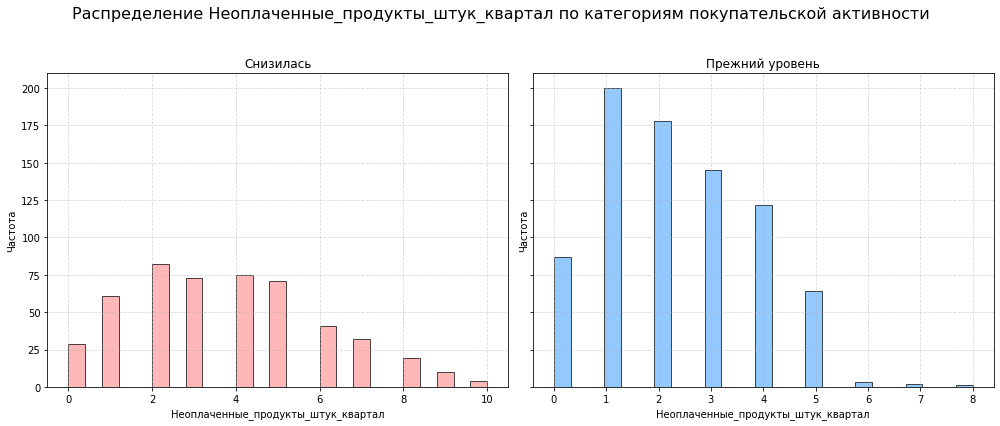


Описательная статистика для Неоплаченные_продукты_штук_квартал по категориям:

Категория: Снизилась
                                    count      mean      std  min  25%  50%  \
Неоплаченные_продукты_штук_квартал  497.0  3.724346  2.28831  0.0  2.0  4.0   

                                    75%   max  
Неоплаченные_продукты_штук_квартал  5.0  10.0  

Категория: Прежний уровень
                                    count      mean       std  min  25%  50%  \
Неоплаченные_продукты_штук_квартал  802.0  2.293017  1.508255  0.0  1.0  2.0   

                                    75%  max  
Неоплаченные_продукты_штук_квартал  3.0  8.0  


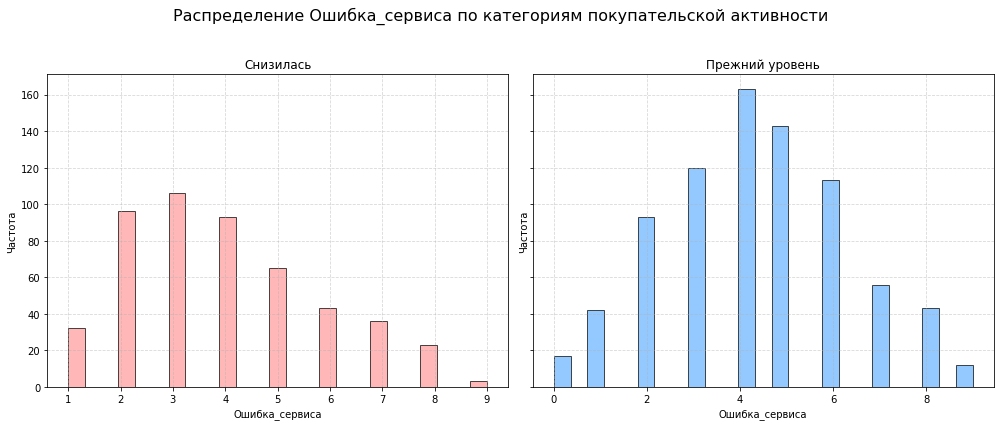


Описательная статистика для Ошибка_сервиса по категориям:

Категория: Снизилась
                count      mean       std  min  25%  50%  75%  max
Ошибка_сервиса  497.0  3.943662  1.894614  1.0  2.0  4.0  5.0  9.0

Категория: Прежний уровень
                count      mean       std  min  25%  50%  75%  max
Ошибка_сервиса  802.0  4.335411  1.979538  0.0  3.0  4.0  6.0  9.0


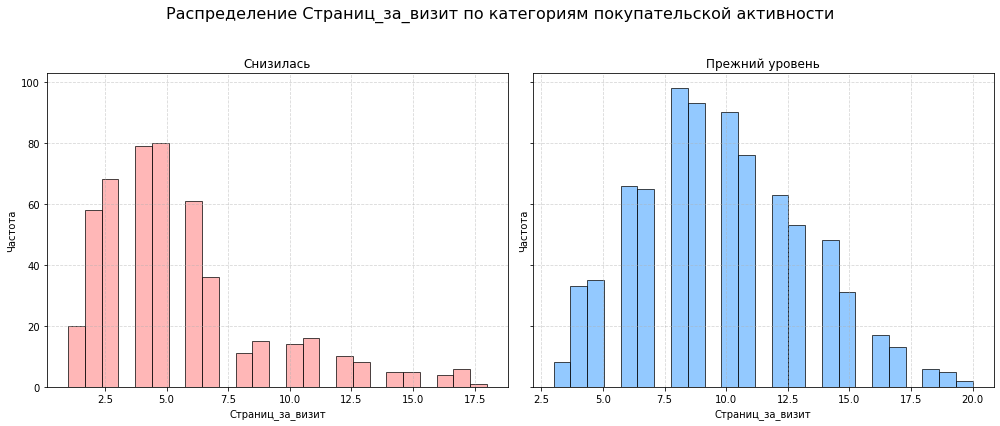


Описательная статистика для Страниц_за_визит по категориям:

Категория: Снизилась
                  count      mean       std  min  25%  50%  75%   max
Страниц_за_визит  497.0  5.565392  3.457147  1.0  3.0  5.0  7.0  18.0

Категория: Прежний уровень
                  count      mean       std  min  25%   50%   75%   max
Страниц_за_визит  802.0  9.796758  3.376846  3.0  7.0  10.0  12.0  20.0


In [27]:
# Определение столбца и категорий для анализа
target_column = 'Покупательская_активность'
activity_categories = ['Снизилась', 'Прежний уровень']

# Получение списка всех столбцов для анализа, исключая 'id'
analyzed_columns = market_file.columns.drop('id')

# Создание графиков и таблиц для каждого столбца
for feature in analyzed_columns:

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    colors = ['#FF9999', '#66B2FF']
    edgecolor = 'black'

    for i, category in enumerate(activity_categories):
        # Отбор данных по категории
        filtered_data = market_file[market_file[target_column] == category][feature].dropna()

        axes[i].hist(filtered_data, bins=25, alpha=0.7, color=colors[i], edgecolor=edgecolor)
        axes[i].set_title(f'{category}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Частота')
        axes[i].grid(True, linestyle='--', alpha=0.5)

    fig.suptitle(f'Распределение {feature} по категориям покупательской активности', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # Выведем точные числовые значения графиков
    print(f'\nОписательная статистика для {feature} по категориям:')
    for category in activity_categories:
        filtered_data = market_file[market_file[target_column] == category][feature]
        print(f'\nКатегория: {category}')
        print(filtered_data.describe().to_frame().T)

Построим диаграммы для категориальных признаков.

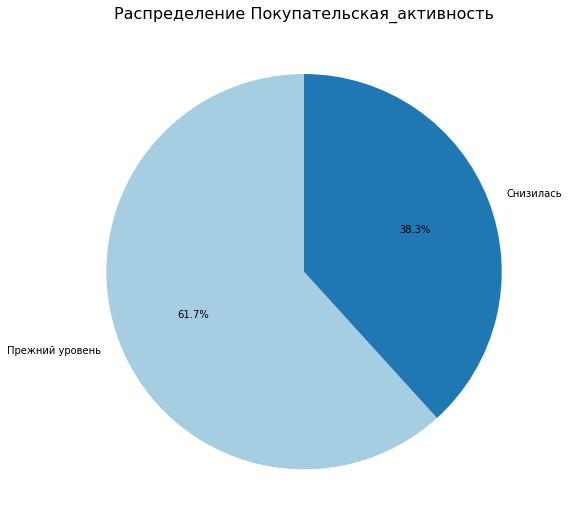

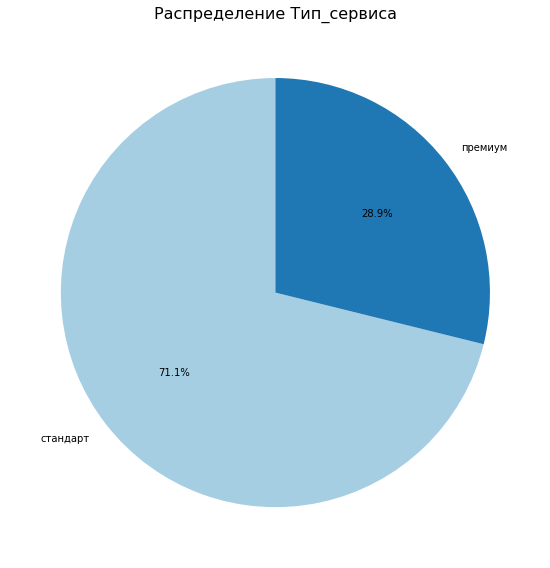

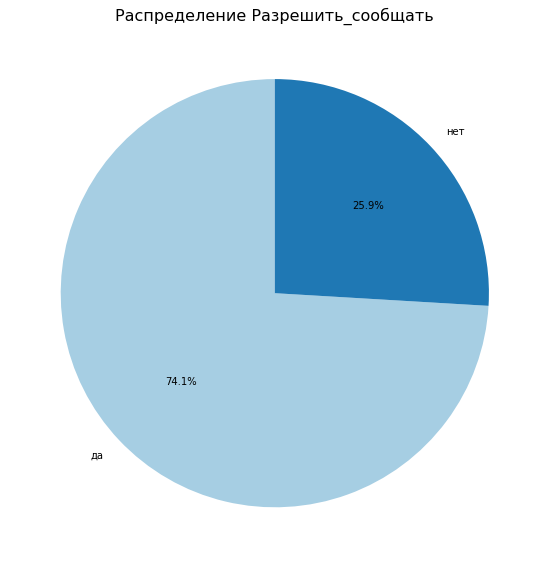

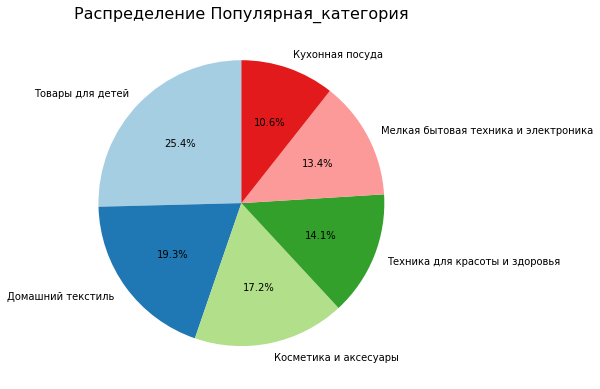

In [28]:
# Определим категориальные признаки и построим для них диаграммы
categorical_columns = market_file.select_dtypes(include=['object', 'category']).columns

for col in categorical_columns:
    plt.figure(figsize=(8, 8))

    value_counts = market_file[col].value_counts()

    plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
    plt.title(f'Распределение {col}', fontsize=16)

    plt.tight_layout()
    plt.show()

Вывод:  
 Не оказалось клиентов, которые не приносили выручку за последние три месяца.

 Большинство клиентов выбирают стандартный тип сервиса, разрешили отправку сообщений и предпочитают категорию "Товары для детей".

_

Покупательская_активность: В категории "Снизилась" 494 наблюдений, а в категории "Прежний уровень" - 802 наблюдения.

Тип_сервиса: В обеих категориях большинство клиентов выбирают "стандарт".

Разрешить_сообщать: Большинство клиентов в обеих категориях разрешили отправку сообщений.

Маркет_актив_6_мес: Средняя активность на рынке за последние 6 месяцев выше у клиентов, чья активность осталась на прежнем уровне.

Маркет_актив_тек_мес: Средняя активность на рынке в текущем месяце примерно одинакова в обеих категориях.

Длительность: Клиенты, чья активность снизилась, в среднем проводят больше времени.

Акционные_покупки: Клиенты, чья активность снизилась, в среднем совершают больше акционных покупок, хотя в обеих категориях есть доля клиентов совершающих вплоть до 99% только акционных покупок.

Популярная_категория: В обеих категориях наиболее популярной является категория "Товары для детей".

Средний_просмотр_категорий_за_визит: Клиенты, чья активность осталась на прежнем уровне, в среднем просматривают больше категорий за визит.

Неоплаченные_продукты_штук_квартал: Клиенты, чья активность снизилась, в среднем имеют больше неоплаченных продуктов за квартал.

Ошибка_сервиса: Клиенты, чья активность осталась на прежнем уровне, в среднем сталкиваются с большим количеством ошибок сервиса.

Страниц_за_визит: Клиенты, чья активность осталась на прежнем уровне, в среднем просматривают больше страниц за визит.


_

Клиенты, чья активность снизилась, в среднем тратят больше времени на сайте и совершают больше покупок по акциям. Это может свидетельствовать о том, что они ищут выгодные предложения и скидки, что, в свою очередь, говорит о их повышенной чувствительности к ценам. Если данное предположение верно, то, например, целевое предложение специальных акций или скидок может способствовать повышению их активности и увеличению выручки. Также стоит проверить уровень цен на сайте, т.к. клиенты покупающие товары только по акциям есть и среди активных пользователей, это означает, что, возможно, есть завышение цен на платформе.

## Шаг 4. Объединение таблиц

In [29]:
# Преобразуем датафрейм
market_money = market_money.pivot(index='id', columns='Период', values='Выручка')
market_money.columns = ['выручка_' + str(col) for col in market_money.columns]

# Упорядочим столбцы
market_money = market_money[['выручка_препредыдущий_месяц', 'выручка_предыдущий_месяц', 'выручка_текущий_месяц']]

# Отсеим клиентов  без покупок
market_money = market_money[(market_money['выручка_препредыдущий_месяц'] != 0) & (market_money['выручка_предыдущий_месяц'] != 0) & (market_money['выручка_текущий_месяц'] != 0)]



In [30]:
market_money.head()

,выручка_препредыдущий_месяц,выручка_предыдущий_месяц,выручка_текущий_месяц
id,,,
215349,4472.0,5216.0,4971.6
215350,4826.0,5457.5,5058.4
215351,4793.0,6158.0,6610.4
215352,4594.0,5807.5,5872.5
215353,5124.0,4738.5,5388.5


In [31]:
# Преобразуем датафрейм, добавим "минут_" к столбцам
market_time = market_time.pivot(index='id', columns='Период', values='минут')
market_time.columns = ['минут_' + str(col) for col in market_time.columns]


In [32]:
market_time.head()

,минут_предыдущий_месяц,минут_текущий_месяц
id,,
215348,13,14
215349,12,10
215350,8,13
215351,11,13
215352,8,11


In [33]:
# Объединяем датафреймы по общему столбцу id
market_file = market_file.merge(market_money, on='id', how='inner')
market_file = market_file.merge(market_time, on='id', how='inner')

In [34]:
# Проверяем какой датафрейм получился
market_file

,id,Покупательская_активность,Тип_сервиса,Разрешить_сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,выручка_препредыдущий_месяц,выручка_предыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,5216.0,4971.6,12,10
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5457.5,5058.4,8,13
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11,13
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8,11
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,5124.0,4738.5,5388.5,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1291,216643,Прежний уровень,стандарт,да,6.6,3,318,0.24,Техника для красоты и здоровья,5,3,3,11,4704.0,3664.0,4741.7,14,7
1292,216644,Прежний уровень,стандарт,нет,5.1,4,454,0.21,Домашний текстиль,6,2,3,9,5299.0,4729.0,5353.0,12,11
1293,216645,Прежний уровень,стандарт,да,4.1,3,586,0.20,Домашний текстиль,3,2,5,7,5334.0,5160.0,5139.2,12,18
1294,216646,Прежний уровень,стандарт,да,6.3,5,645,0.12,Техника для красоты и здоровья,3,3,5,7,4725.0,4923.0,5224.6,18,7


## Шаг 5. Корреляционный анализ

interval columns not set, guessing: ['id', 'Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность', 'Акционные_покупки', 'Средний_просмотр_категорий_за_визит', 'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса', 'Страниц_за_визит', 'выручка_препредыдущий_месяц', 'выручка_предыдущий_месяц', 'выручка_текущий_месяц', 'минут_предыдущий_месяц', 'минут_текущий_месяц']


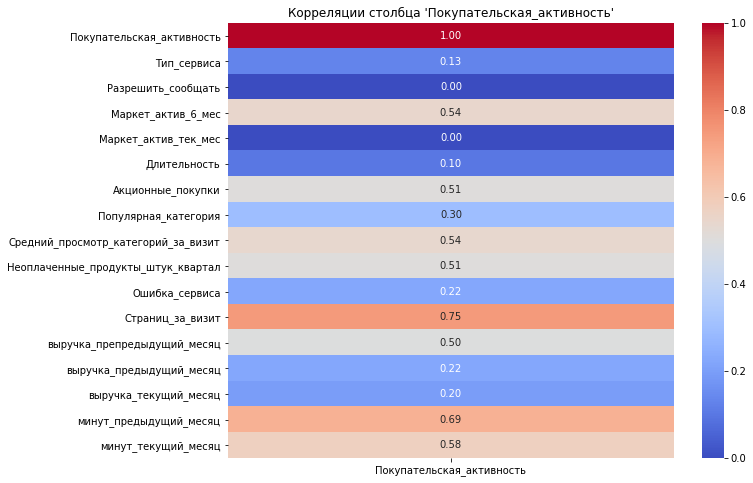

In [35]:
# Отобразим тепловую карту корреляции для столбца 'Покупательская_активность'
# Столбец 'id' предварительно исключим т.к. у него нет смысловой нагрузки, это просто индексы
phik_matrix = market_file.phik_matrix().drop(index='id', columns=['id'])
plt.figure(figsize=(10, 8))
sns.heatmap(phik_matrix[["Покупательская_активность"]], annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Корреляции столбца 'Покупательская_активность'")
plt.show()

Столбцы: Маркет_актив_6_мес, Акционные_покупки, Средний_просмотр_категорий_за_визит, Неоплаченные_продукты_штук_квартал и Страниц_за_визит имеют умеренную положительную корреляцию с покупательской активностью, что может указывать на то, что эти признаки влияют на поведение клиентов и их склонность к покупкам.

Столбцы: Тип сервиса, Длительность, Популярная_категория, Ошибка_сервиса, выручка_препредыдущий_месяц, выручка_предыдущий_месяц, выручка_текущий_месяц, общая_выручка, минут_предыдущий_месяц, минут_текущий_месяц и общее_время_на_сайте имеют слабую положительную корреляцию с покупательской активностью.

Столбцы: Разрешить сообщать и Маркет_актив_тек_мес имеют нулевую корреляцию с покупательской активностью.

interval columns not set, guessing: ['id', 'Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность', 'Акционные_покупки', 'Средний_просмотр_категорий_за_визит', 'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса', 'Страниц_за_визит', 'выручка_препредыдущий_месяц', 'выручка_предыдущий_месяц', 'выручка_текущий_месяц', 'минут_предыдущий_месяц', 'минут_текущий_месяц']


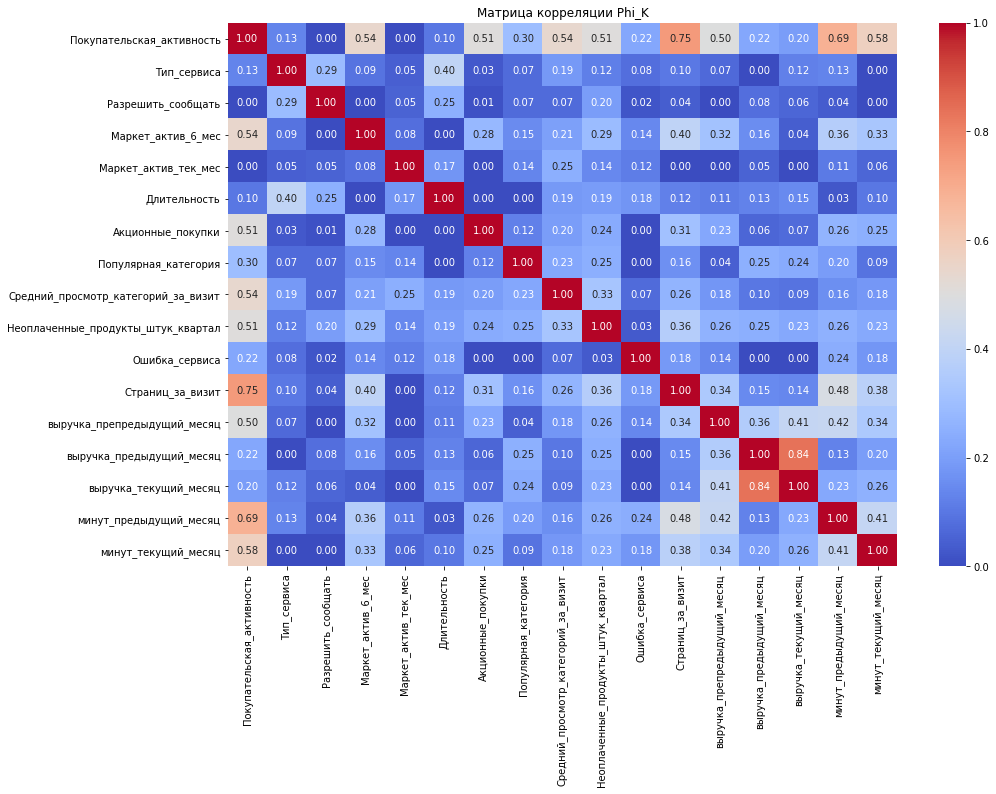

In [36]:
# Ещё построим матрицу корреляции для данных без 'id'
phik_matrix = market_file.phik_matrix().drop(index='id', columns=['id'])

plt.figure(figsize=(15, 10))
sns.heatmap(phik_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Матрица корреляции Phi_K")
plt.show()

Сильная корреляция наблюдается между столбцами выручка_предыдущий_месяц и выручка_текущий_месяц (0.84), что указывает на схожесть поведения этих показателей. Это может означать, что клиенты, показывающие высокую выручку в предыдущем месяце, продолжают оставаться активными в текущем.
Важно учесть возможную мультиколлинеарность между вышеуказанными столбцами, так как сильная корреляция может привести к проблемам в регрессионных моделях. Возможно, потребуется исключить один из этих показателей или использовать методы регуляризации.

Просмотренные страницы и время, проведённое на сайте (минуты) также имеют заметную корреляцию с покупательской активностью, особенно Просмотренные страницы (0.75) и минут_предыдущий_месяц (0.69). Это может указывать на значительное влияние текущей активности и вовлечённости на покупательское поведение.

Однако корреляция не гарантирует причинно-следственную связь, и дополнительный анализ может быть необходим для определения важности этих признаков

## Шаг 6. Использование пайплайнов

In [37]:
# Создаём датафрейм без столбца id
df_mod = market_file.drop('id', axis=1)

In [38]:
# Заменим значения в столбце Покупательская_активность
df_mod['Покупательская_активность'] = df_mod['Покупательская_активность'].replace({'Снизилась': 1, 'Прежний уровень': 0})

In [39]:
# Задаем параметры для разделения данных
RANDOM_STATE = 222
TEST_SIZE = 0.20

# Определение целевого признака
target = 'Покупательская_активность'

# Получение списка всех признаков, за исключением целевого
features = df_mod.columns.drop(target)

# Определение числовых и текстовых признаков
num_columns = df_mod[features].select_dtypes(include=['int64', 'float64']).columns.tolist()
ohe_columns = df_mod[features].select_dtypes(include=['object']).columns.tolist()

# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    df_mod.drop(target, axis=1),  # Независимые переменные
    df_mod[target],  # Зависимая переменная
    test_size=TEST_SIZE,  # Размер тестовой выборки
    random_state=RANDOM_STATE  # Случайное состояние для воспроизводимости
)

# Пайплайн для OHE
ohe_pipe = Pipeline(
    [('ohe', OneHotEncoder(drop='first', sparse_output=False))]
)

# Пайплайн для OHE и OE
ohe_oe_pipe = Pipeline(
    [('ohe', OneHotEncoder(drop='first', sparse_output=False)),
     ('oe', OrdinalEncoder())]
)

# Создаем общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('num', MinMaxScaler(), num_columns),
    ], verbose_feature_names_out = False,
    remainder='passthrough'
)

# Пайплайн с OHE и OE для дерева решений
data_preprocessor_tree = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('oe', OrdinalEncoder(), ohe_columns),
        ('num', MinMaxScaler(), num_columns)
    ],
    remainder='passthrough'
)

# Создаем финальный пайплайн
pipe_final = Pipeline([
    ('preprocessor', 'passthrough'),
    ('model', 'passthrough')
])

# Создаем список словарей для каждой модели
param_grid = [
    # словарь для модели DecisionTreeClassifier с OHE и OE
    {
        'model': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'model__max_depth': range(2, 10),
        'model__max_features': range(2, 10),
        'preprocessor': [data_preprocessor_tree]
    },
    # словарь для модели KNeighborsClassifier()
    {
        'model': [KNeighborsClassifier()],
        'model__n_neighbors': range(1, 6),
        'preprocessor': [data_preprocessor]
    },
    # словарь для модели LogisticRegression()
    {
        'model': [LogisticRegression(solver='liblinear', penalty='l1', random_state=RANDOM_STATE)],
        'model__C': [0.01, 0.1, 1, 10, 100],
        'preprocessor': [data_preprocessor]
    },
 # словарь для модели SVC
    {
        'model': [SVC(probability=True, random_state=RANDOM_STATE)],
        'model__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
        'model__C': [0.1, 1, 10,],
        'preprocessor': [data_preprocessor]
    }
]

grid = GridSearchCV(
    pipe_final,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid.fit(X_train, y_train)
print('Лучшая модель и её параметры:\n\n', grid.best_estimator_)
print('Метрика лучшей модели на тренировочной выборке:', grid.best_score_)
y_test_pred = grid.predict(X_test)
roc_auc = roc_auc_score(y_test, y_test_pred)
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc:.4f}')

# Предсказание вероятностей классов
probabilities = grid.predict_proba(X_test)

# Извлечение вероятностей для класса 1
probabilities_one = probabilities[:, 1]

# Вычисление ROC-AUC
roc_auc = roc_auc_score(y_test, probabilities_one)
print(f'Метрика ROC-AUC для класса 1 на тестовой выборке: {roc_auc:.4f}')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['Тип_сервиса',
                                                   'Разрешить_сообщать',
                                                   'Популярная_категория']),
                                                 ('num', MinMaxScaler(),
                                                  ['Маркет_актив_6_мес',
                                                   'Маркет_актив_тек_мес',
                                                   'Длительность',
                                       

Выбрали метрику ROC-AUC, потому что она устойчива к дисбалансу классов, а у нас как раз дисбаланс есть, имеет независимость от порога классификации, и ROC-кривая позволяет визуализировать качество модели и сравнивать ее с другими моделями.

В результате выполнения анализа была отобрана оптимальная модель — SVC (Метод опорных векторов) с параметрами C=1, probability=True, random_state=222. Перед обучением модель применялась к данным, которые были предварительно обработаны с помощью OneHotEncoder для категориальных признаков и MinMaxScaler для числовых признаков.

На тренировочной выборке модель продемонстрировала метрику ROC-AUC 0.9062, что свидетельствует о хорошем уровне обучения и способности выявлять закономерности в данных. Метрика ROC-AUC на тестовой выборке составила 0.8846, что указывает на высокую способность модели к обобщению на новых данных и подтверждает её стабильную работу вне тренировочного набора. Метрика ROC-AUC для вероятностей класса 1 на тестовой выборке достигла 0.9167, что также говорит о точной оценке вероятностей принадлежности к классу, а не только о предсказании меток классов.

Таким образом, выбранная модель SVC продемонстрировала высокие показатели эффективности и надёжности. Её можно рекомендовать для прогнозирования покупательской активности на основе имеющихся данных, однако стоит продолжить анализ, чтобы выявить дополнительные возможности для улучшения модели и её применения.

## Шаг 7. Анализ важности признаков

Построим график важности признаков для победившей модели.

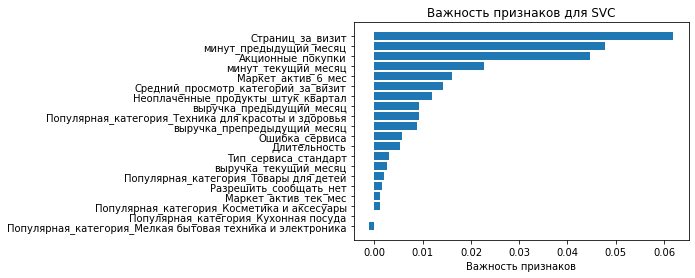

In [40]:
# Применяем препроцессор к тестовым данным
X_test_transformed = grid.best_estimator_.named_steps['preprocessor'].transform(X_test)

# Вычисляем важность признаков с помощью перестановочной важности для лучшей модели (SVC)
result = permutation_importance(grid.best_estimator_.named_steps['model'], X_test_transformed, y_test, n_repeats=10, random_state=RANDOM_STATE)

# Сортируем важности
sorted_idx = result.importances_mean.argsort()

# Получаем имена признаков из препроцессора
feature_names = grid.best_estimator_.named_steps['preprocessor'].transformers_[0][1].named_steps['ohe'].get_feature_names_out(ohe_columns).tolist()
feature_names.extend(num_columns)  # Добавляем числовые признаки

# Создаем график важности признаков
plt.barh(range(len(sorted_idx)), result.importances_mean[sorted_idx], yerr=result.importances_std[sorted_idx])
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel("Важность признаков")
plt.title("Важность признаков для SVC")
plt.show()

Построим график важности признаков методом SHAP

  0%|          | 0/50 [00:00<?, ?it/s]

SHAP values shape: (50, 20)
X_test_transformed shape: (50, 20)


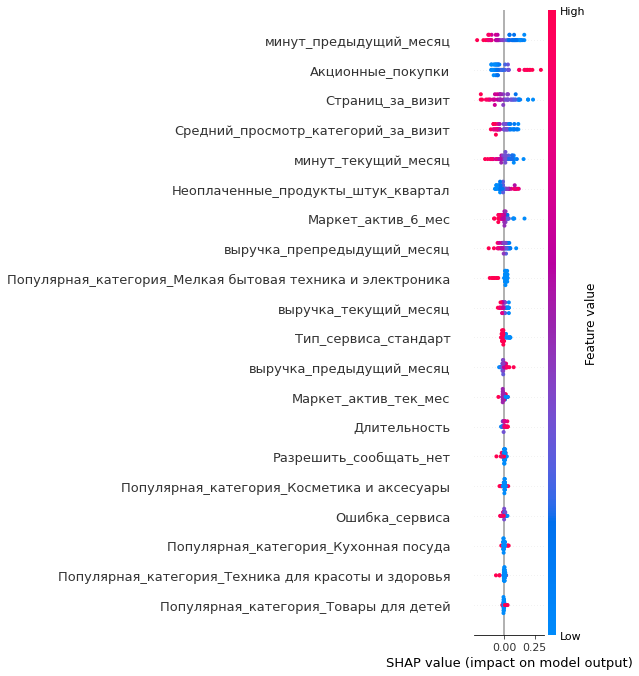

In [41]:
# Извлекаем лучший пайплайн
best_pipeline = grid.best_estimator_

# Преобразуем тестовые данные 
X_test_transformed = best_pipeline.named_steps['preprocessor'].transform(X_test)

# Создаем DataFrame с правильными названиями признаков
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
X_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_names)

# Ограничиваем тестовые данные первыми 50 элементами для ускорения загрузки
X_test_transformed = X_test_transformed.iloc[:50]
y_test = y_test[:50] if isinstance(y_test, pd.Series) else y_test[:50].tolist()

# Извлекаем модель из лучшего пайплайна
best_model = best_pipeline.named_steps['model']

# Создаем функцию-обертку для predict_proba
def model_predict(X):
    return best_model.predict_proba(X)[:, 1]

# Создаем объект объяснителя SHAP для модели SVC
explainer = shap.KernelExplainer(model_predict, X_test_transformed)

# Вычисляем значения SHAP для тестовых данных
shap_values = explainer.shap_values(X_test_transformed)

# Проверяем форму shap_values и X_test_transformed
print(f"SHAP values shape: {shap_values.shape}")
print(f"X_test_transformed shape: {X_test_transformed.shape}")

# Убедитесь, что количество строк в shap_values совпадает с количеством строк в X_test_transformed
assert shap_values.shape == X_test_transformed.shape, "SHAP values and X_test_transformed shape do not match!"

# Визуализируем важность признаков
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

Важные признаки, которые определяют покупательскую активность:

- num_минут_предыдущий_месяц: Этот признак отражает, сколько времени покупатель провёл на сайте за прошлый месяц. Его SHAP значение имеет значительный отрицательный знак, что говорит о том, что чем больше времени покупатель проводит на сайте, тем меньше вероятность снижения его активности.

- num_Страницы_за_визит: Показывает среднее количество страниц, которые покупатель посещал за один визит на сайте в последние три месяца. Этот признак также имеет отрицательное SHAP значение, что указывает на то, что чем больше страниц посетил пользователь, тем выше его активность.

- num_Средний_просмотр_категории_за_визит: Данный признак отражает среднее количество категорий товаров, которые покупатель просматривал за один визит в течение последнего месяца. Хотя его SHAP значение также отрицательное, оно не столь выраженное, как у первых двух признаков.

- num_Акционные покупки: Рассчитывает долю покупок, сделанных по акциям за последние полгода. Этот признак имеет положительное SHAP значение, что указывает на то, что чем больше акционных покупок совершает клиент, тем выше риск снижения его активности.

- num_Неоплаченные продукты штука квартал: Считает, сколько товаров покупатель оставил в корзине неоплаченными за последние три месяца. Положительное значение SHAP говорит о том, что увеличение этого показателя также связано с падением покупательской активности.

- num_минут текущий месяц: Отражает количество времени, которое пользователь проводит на сайте в текущем месяце. Хотя SHAP значение этого признака отрицательное, его влияние не столь значительное, как у признака "num_минут_предыдущий_месяц".

- num_Маркет актив 6 мес: Определяет, сколько маркетинговых акций (рекламы, рассылок и других форм коммуникаций) достигло покупателя за последние шесть месяцев. Отрицательное SHAP значение показывает, что чем больше маркетинговых касаний, тем выше активность клиента.

- one_Популярная категория Мелкая бытовая техника и электроника: Этот признак отражает категорию товаров, которая была самой востребованной у покупателя за последние полгода. Его отрицательное SHAP значение свидетельствует о том, что интерес к популярным категориям коррелирует с сохранением покупательской активности.

- num_выручка препредыдущий месяц: Этот признак показывает, сколько денег потратил клиент за два месяца до текущего. Его отрицательное SHAP значение указывает, что чем выше сумма покупок, тем более активен клиент.

Таким образом, признаки с отрицательными SHAP значениями, такие как время, проведённое на сайте, и количество страниц, посещённых за визит, свидетельствуют о большей активности покупателей. В то время как признаки с положительными значениями, например, акционные покупки и неоплаченные товары, чаще связаны с уменьшением активности.


Эти выводы могут помочь вам лучше понять, какие факторы влияют на покупательскую активность ваших клиентов, и как можно оптимизировать свои стратегии продаж. В частности, вы можете:

Мотивировать активных клиентов: Тем, кто проводит много времени на сайте и активно просматривает страницы и категории, можно предложить скидки, бонусы или персонализированные рекомендации для поддержания интереса и увеличения конверсии.

Работа с акционными покупателями: Покупателям, которые часто совершают покупки по акциям, можно предлагать товары с большей маржой или постепенно повышать цены на акционные позиции, чтобы увеличить прибыль без снижения их активности.

Снижение числа брошенных корзин: Можно уменьшить количество неоплаченных товаров в корзине, отправляя клиентам напоминания, предлагая бесплатную доставку или гарантию возврата, чтобы стимулировать завершение покупки.

Интенсификация маркетинговых коммуникаций: Для клиентов, которые редко посещают сайт или мало тратят, можно увеличить частоту маркетинговых касаний (например, рассылки, уведомления), чтобы повысить их интерес к вашему ассортименту и укрепить лояльность.

Анализ и оптимизация ассортимента: Проанализируйте популярные категории товаров среди ваших клиентов и сосредоточьте усилия на оптимизации ассортимента, стратегии ценообразования и продвижения этих категорий для повышения продаж.

Эти шаги помогут вам более эффективно влиять на поведение клиентов и стимулировать их к покупкам.

## Шаг 8. Сегментация покупателей

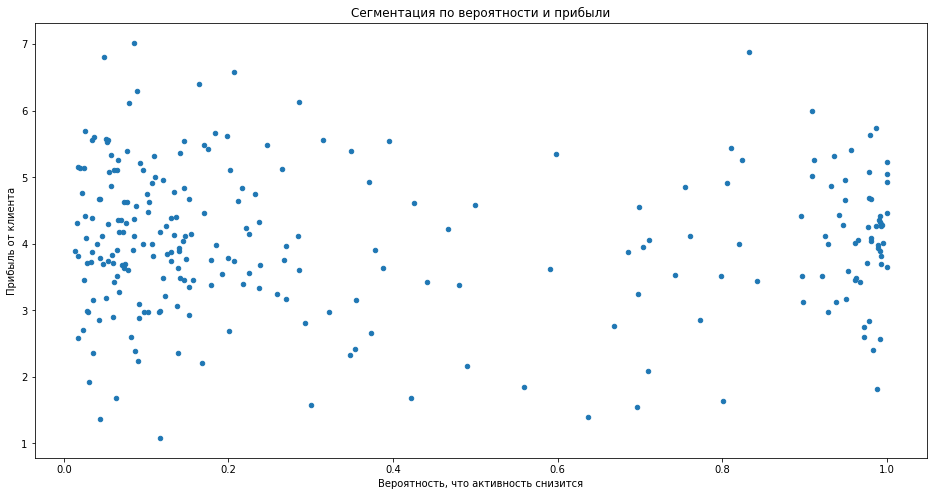

In [42]:
# Возьмём id из датафрейма
ids = market_file['id']

# Получаем предсказанные вероятности для класса 1
predicted = grid.predict_proba(X_test)[:, 1]

# Добавляем предсказанные вероятности в тестовый набор данных
X_test['predicted'] = predicted

# Восстанавливаем столбец 'id' в X_test
X_test['id'] = ids.iloc[X_test.index]

# Объединяем с исходным датафреймом money по столбцу 'id'
segment = X_test.merge(money, on='id')

# Построение графика
segment.plot.scatter(x='predicted', y='Прибыль', figsize=(16, 8))
plt.xlabel('Вероятность, что активность снизится')
plt.ylabel('Прибыль от клиента')
plt.title('Сегментация по вероятности и прибыли')
plt.show()

Будем рассматривать клиентов у которых высока вероятность, что их активность снизится, но при этом их прибыль больше средней. Т.е. это клиенты прибыль от которых вероятно уменьшится в будущем, что в свою очередь уменьшит прибыль компании, поэтому стоит обратить внимание на данных клиентов.

In [43]:
segment = segment[(segment['predicted'] >= 0.6) & (segment['Прибыль'] >= segment['Прибыль'].mean())]

In [44]:
# Построим тепловую карту
segment.drop('id', axis = 1).phik_matrix().style.background_gradient(cmap ='coolwarm')

interval columns not set, guessing: ['Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность', 'Акционные_покупки', 'Средний_просмотр_категорий_за_визит', 'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса', 'Страниц_за_визит', 'выручка_препредыдущий_месяц', 'выручка_предыдущий_месяц', 'выручка_текущий_месяц', 'минут_предыдущий_месяц', 'минут_текущий_месяц', 'predicted', 'Прибыль']


,Тип_сервиса,Разрешить_сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,выручка_препредыдущий_месяц,выручка_предыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц,predicted,Прибыль
Тип_сервиса,1.000000,0.000000,0.405821,0.186035,0.596655,0.307270,0.000000,0.000000,0.547254,0.000000,0.250802,0.693565,0.000000,0.000000,0.175251,0.000000,0.000000,0.000000
Разрешить_сообщать,0.000000,1.000000,0.064176,0.000000,0.643454,0.000000,0.258751,0.000000,0.000000,0.200878,0.000000,0.000000,0.000000,0.000000,0.000000,0.572126,0.126272,0.000000
Маркет_актив_6_мес,0.405821,0.064176,1.000000,0.306291,0.000000,0.000000,0.000000,0.000000,0.000000,0.452685,0.093980,0.000000,0.000000,0.000000,0.691690,0.265661,0.000000,0.000000
Маркет_актив_тек_мес,0.186035,0.000000,0.306291,1.000000,0.327247,0.309650,0.617794,0.173570,0.528820,0.403656,0.000000,0.514190,0.000000,0.297601,0.583099,0.394570,0.000000,0.489018
Длительность,0.596655,0.643454,0.000000,0.327247,1.000000,0.000000,0.313525,0.561982,0.451135,0.202551,0.224415,0.349904,0.000000,0.657143,0.000000,0.000000,0.000000,0.000000
Акционные_покупки,0.307270,0.000000,0.000000,0.309650,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.356077,0.457742,0.000000,0.000000,0.220490,0.000000,0.499427,0.280526
Популярная_категория,0.000000,0.258751,0.000000,0.617794,0.313525,0.000000,1.000000,0.000000,0.000000,0.143477,0.000000,0.301779,0.490482,0.597936,0.499840,0.000000,0.642829,0.000000
Средний_просмотр_категорий_за_визит,0.000000,0.000000,0.000000,0.173570,0.561982,0.000000,0.000000,1.000000,0.297962,0.000000,0.216277,0.000000,0.000000,0.578573,0.000000,0.132620,0.694573,0.000000
Неоплаченные_продукты_штук_квартал,0.547254,0.000000,0.000000,0.528820,0.451135,0.000000,0.000000,0.297962,1.000000,0.313893,0.339148,0.123385,0.393056,0.585176,0.000000,0.000000,0.000000,0.000000
Ошибка_сервиса,0.000000,0.200878,0.452685,0.403656,0.202551,0.000000,0.143477,0.000000,0.313893,1.000000,0.361374,0.000000,0.086886,0.471070,0.365996,0.000000,0.335773,0.170827


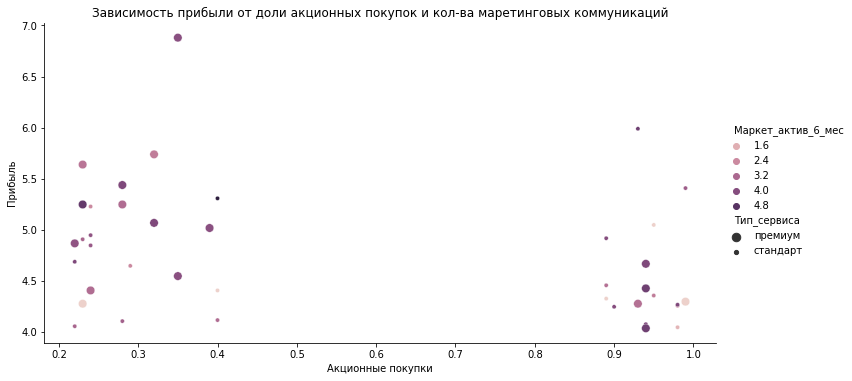

In [45]:
# Построим график зависимости для прибыли от доли акционных покупок и маркет. коммуникаций
sns.relplot(data = segment, x = 'Акционные_покупки', y ='Прибыль', hue = 'Маркет_актив_6_мес', size = 'Тип_сервиса', aspect = 2)
plt.title('Зависимость прибыли от доли акционных покупок и кол-ва маретинговых коммуникаций')
plt.xlabel('Акционные покупки')
plt.ylabel('Прибыль')
plt.show()

In [46]:
# Посмотрим сводную таблицу по страниц за визит и тип сервиса
pivot_table = segment.pivot_table(index=['Страниц_за_визит', 'Тип_сервиса'], aggfunc='size')
pivot_table

Страниц_за_визит  Тип_сервиса
1                 стандарт       3
2                 премиум        2
                  стандарт       5
3                 премиум        2
                  стандарт       1
4                 премиум        4
                  стандарт       6
5                 премиум        2
                  стандарт       3
6                 премиум        3
                  стандарт       1
7                 премиум        4
                  стандарт       2
8                 стандарт       2
dtype: int64

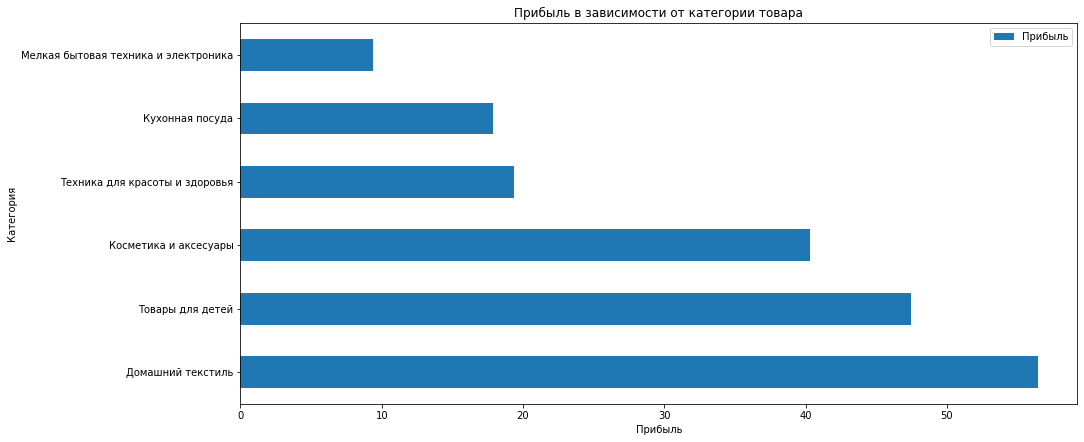

In [47]:
# Построим диаграмму прибыльности категорий товаров
segment.groupby('Популярная_категория')['Прибыль'].sum().sort_values(ascending = False).plot(kind = 'barh', legend = True, figsize = (15, 7))
plt.title('Прибыль в зависимости от категории товара')
plt.ylabel('Категория')
plt.xlabel('Прибыль')
plt.show()

In [48]:
# Посмотрим сводную таблицу по популярной категории
pivot_table = segment.pivot_table(index='Популярная_категория', aggfunc='size')

print(pivot_table)

Популярная_категория
Домашний текстиль                       12
Косметика и аксесуары                    8
Кухонная посуда                          4
Мелкая бытовая техника и электроника     2
Техника для красоты и здоровья           4
Товары для детей                        10
dtype: int64


Мы рассмотрели сегмент покупателей с повышенной прибылью и при этом повышенной вероятностью к её возможному снижению.  

Рекомендации, которую можно дать бизнесу:

 - Клиенты премиум мало используют акционные предложения, возможно стоит их как-то видоизменить, персонализировать, чтобы сделать их более популярными в этой группе.
 - Прибыль и удержание клиентов не сильно зависит от маркет. активности, а значит нужно сосредоточить своё внимание на более важных вещах
 - Наиболее популярные категории товаров - "Товары для детей" и "Косметика и аксессуары". Но при этом доли акционных покупок там одни из самых низких. Для удержание клиентов этих категорий стоит добавить акций/персональных предложений.
 - Пользователи, посещающие мало страниц за визит, имеют одни из самых наибольших вероятностей, на снижение своей активности.    - Необходимо придумать что-нибудь, для их дальнейшего удержания, например систему рекомендаций товаров или предоставление какого-нибудь удобного сервиса.

## Шаг 9. Общий вывод

В рамках проекта для интернет-магазина «В один клик» было разработано решение, направленное на повышение покупательской активности постоянных клиентов через персонализированные предложения. Основной задачей стало предсказание вероятности снижения активности покупателей в течение следующих трёх месяцев, сегментация пользователей и создание индивидуальных предложений для каждой группы.

Предобработка данных
Исходные данные состояли из четырёх наборов: Market File, Market Money, Market Time и Money. В процессе предобработки данных были исправлены опечатки, удалены аномалии и объединены таблицы для последующего анализа. Также был выполнен исследовательский анализ данных для выявления ключевых закономерностей.

Поиск лучшей модели
Для выбора наиболее эффективной модели использовались четыре алгоритма классификации:

- Логистическая регрессия,
- k-ближайших соседей,
- Дерево решений,
- Метод опорных векторов (SVM).
Для каждого алгоритма была проведена кросс-валидация и настроены гиперпараметры. Основной метрикой оценки качества моделей стал показатель ROC-AUC.

Лучшая модель
SVC (Метод опорных векторов) с параметрами C=1, probability=True, random_state=222 показала наилучший результат с ROC-AUC ~ 0.92. Эта модель выявила основные факторы, влияющие на активность покупателей:

- Время, проведённое на сайте,
- Количество просмотренных страниц и категорий,
- Доля акционных покупок,
- Количество неоплаченных товаров,
- Участие в маркетинговых акциях,
- Популярные категории товаров,
- Общая сумма потраченных средств.
- Сегментация покупателей

Рассмотрели сегмент покупателей с повышенной прибылью и при этом повышенной вероятностью к её возможному снижению.

- Клиенты премиум мало используют акционные предложения, возможно стоит их как-то видоизменить, персонализировать, чтобы сделать их более популярными в этой группе.
- Прибыль и удержание клиентов не сильно зависит от маркет. активности, а значит нужно сосредоточить своё внимание на более важных вещах
- Наиболее популярные категории товаров - "Товары для детей" и "Косметика и аксессуары". Но при этом доли акционных покупок там одни из самых низких. Для удержание клиентов этих категорий стоит добавить акций/персональных предложений.
- Пользователи, посещающие мало страниц за визит, имеют одни из самых наибольших вероятностей, на снижение своей активности. - - - Необходимо придумать что-нибудь, для их дальнейшего удержания, например систему рекомендаций товаров или предоставление какого-нибудь удобного сервиса.

Предложенные меры направлены на повышение активности клиентов и удержание их на сайте. Эффективность рекомендаций может быть оценена с помощью A/B тестирования и других методов анализа.